In [1]:
import matplotlib.pyplot as plt  # For plotting results; optional
import numpy as np

from landlab import RasterModelGrid  # Grid utility
from landlab import imshow_grid  # For plotting results; optional
from landlab.components import Space  # SPACE model
from landlab.components import DepressionFinderAndRouter, FlowAccumulator


from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler

In [2]:
num_rows = 50
num_cols = 100
dxy = 50

mg = RasterModelGrid((num_rows, num_cols), xy_spacing=dxy)

# adding fields
z = mg.add_zeros('topographic__elevation', at='node', clobber=True)

soil = mg.add_zeros("soil__depth", at="node", clobber = True)


In [3]:
# set random roughness of terrain 
np.random.seed(42)

#define where the mountain front is - this can be changed if we want more area for the lowland 
front_y = 0.5 * mg.y_of_node.max()

#initial slopes 
basin_slope = 0.05  #can change these
upland_slope = 0.03

# initiate drainage 
roughness = 0.05 * np.random.rand(mg.number_of_nodes)

# ID upland nodes 
upland = mg.y_of_node >= front_y

#create the distinct highland/lowland 
z[upland] += (50.0 + upland_slope * (mg.y_of_node[upland] - front_y))
z[:] += roughness 

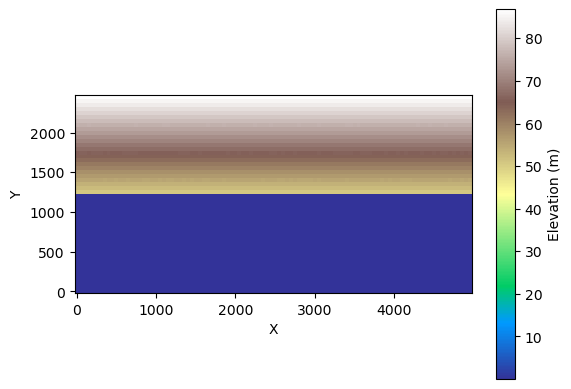

In [4]:
imshow_grid(mg,"topographic__elevation", cmap="terrain",
    colorbar_label="Elevation (m)")

In [5]:
#bedrock here means topography (to begin with) 
soil[:] = 0
bedrock = mg.add_field("bedrock__elevation", z - soil, at="node", clobber=True)


#soil = mg.add_zeros("soil__depth", at="node", clobber=True)

In [6]:
# boundary conditons so that only the bottom is open 
mg.set_closed_boundaries_at_grid_edges(bottom_is_closed=False, left_is_closed=True, right_is_closed=True, top_is_closed=True)

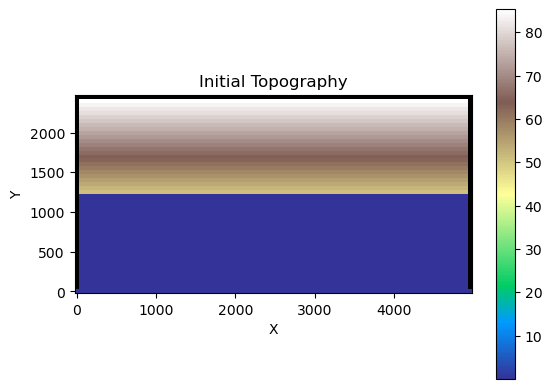

In [7]:
# Let's see our initial topographyyyy 
imshow_grid(mg, "topographic__elevation", cmap="terrain")
plt.title("Initial Topography")
plt.show()

In [8]:
#COMPONENTS!

# Instantiate flow router
fr = FlowAccumulator(mg, flow_director="FlowDirectorD8")

# Instantiate SPACE model with chosen parameters
sp = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=5.0,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [9]:
# 1. Define which nodes are upland and which are lowland 
upland_core_nodes = mg.core_nodes[mg.y_of_node[mg.core_nodes] >= front_y]

basin_core_nodes = np.where(mg.y_of_node < front_y)[0]

In [18]:
#2. Set up uplift, time step, and total run time - Able to change and mess with 
uplift_rate = 0.0005 # m/yr
timestep = 100 #years
run_time = 5000 #years
count = 0 #set timestep count to zero 
n_steps = int(run_time / timestep) 

In [19]:
#3. Track max sed thickness 
model_time = np.zeros(n_steps)
max_basin_soil = np.zeros(n_steps)

In [20]:
#4. The loop that incorporates uplift and sed flux... 

for count in range(n_steps):
    
#HIGHLANDS
    # Uplift bedrock in the upland (this is causing erosion)
    uplift_amount = uplift_rate * timestep

    #Upland cores only 
    bedrock[upland_core_nodes] += uplift_amount
    z[upland_core_nodes] += uplift_amount

    # Recalculate flow on the uplifted/evolving surface
    fr.run_one_step()

#LOWLANDS
    # Sed Flux to the lowlands 
    #sed_flux = _____ 

    #Lowland cores only - deposit sediment

    #recalculate flow/sediment on the lowland surface 
    
    
    # Erode, transport, and deposit sediment to lowland surface 
    sp.run_one_step(dt=timestep)

    # Save results
    model_time[count] = (count + 1) * timestep
    max_basin_soil[count] = soil[basin_core_nodes].max()

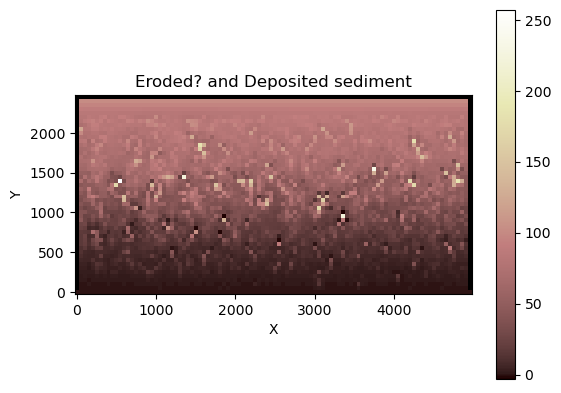

In [21]:
imshow_grid(
    mg,
    "topographic__elevation",
)

plt.title("Eroded? and Deposited sediment")
plt.show()

# To try
* More sediment
* keep timestep at 100 but slow down uplift
See if things work. Run it for longer. Then cut grid in half.
Likely will need to run for 10,000 years at least.
* Could be interesting to see how noise in the lowlands would complicate things.